In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchsummary import summary
import cv2
import matplotlib.pyplot as plt
import os
import numpy as np

if torch.cuda.is_available():
	print("PyTorch is using the GPU")
	GPUCount = torch.cuda.device_count()
	print(f"Found {GPUCount} GPUs")

	for i in range(GPUCount):
		print(f"GPU {i} found: {torch.cuda.get_device_name(i)}")

	device = torch.device("cuda:0")
else:
	print("PyTorch is using the CPU")
	device = torch.device("cpu")

print(f"Selected Device: {device}")

PyTorch is using the GPU
Found 1 GPUs
GPU 0 found: NVIDIA GeForce RTX 5070 Laptop GPU
Selected Device: cuda:0


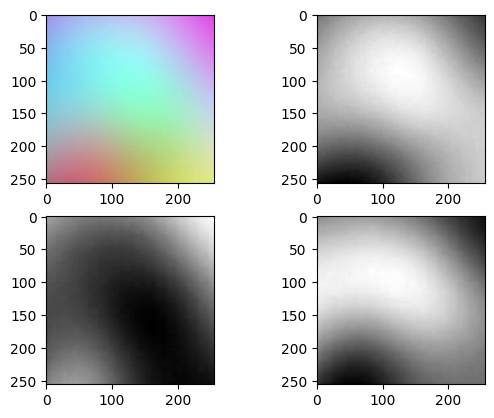

In [2]:
InputImg = cv2.imread('Test.png')
LABImg = cv2.cvtColor(InputImg,cv2.COLOR_RGB2LAB)

plt.subplot(2,2,1)
plt.imshow(cv2.cvtColor(InputImg,cv2.COLOR_BGR2RGB))
plt.subplot(2,2,2)
plt.imshow(LABImg[:,:,0],cmap='gray') #L
plt.subplot(2,2,3)
plt.imshow(LABImg[:,:,1],cmap='gray') #A
plt.subplot(2,2,4)
plt.imshow(LABImg[:,:,2],cmap='gray') #B

In [3]:
class PrismModel(nn.Module):
	def __init__(self):
		super().__init__()

		self.DownConv1 = nn.Conv2d(in_channels=1,out_channels=64,kernel_size=(3,3),padding=1)
		self.DownConv2 = nn.Conv2d(in_channels=64,out_channels=128,kernel_size=(3,3),padding=1)
		self.DownConv3 = nn.Conv2d(in_channels=128,out_channels=256,kernel_size=(3,3),padding=1)
		self.DownConv4 = nn.Conv2d(in_channels=256,out_channels=512,kernel_size=(3,3),padding=1)
		self.UpConv1 = nn.Conv2d(in_channels=768,out_channels=256,kernel_size=(3,3),padding=1)
		self.UpConv2 = nn.Conv2d(in_channels=384,out_channels=128,kernel_size=(3,3),padding=1)
		self.UpConv3 = nn.Conv2d(in_channels=192,out_channels=64,kernel_size=(3,3),padding=1)
		self.UpConv4 = nn.Conv2d(in_channels=64,out_channels=2,kernel_size=(3,3),padding=1)
		self.MaxPool1 = nn.MaxPool2d((2,2))
		self.UpSample1 = nn.Upsample(scale_factor=2,mode='bilinear')
		self.silu = nn.SiLU()

	def forward(self,x):
		x1 = self.silu(self.DownConv1(x))
		x2 = self.MaxPool1(x1)
		x2 = self.silu(self.DownConv2(x2))
		x3 = self.MaxPool1(x2)
		x3 = self.silu(self.DownConv3(x3))
		x4 = self.MaxPool1(x3)
		x4 = self.silu(self.DownConv4(x4))
		x4 = self.UpSample1(x4)
		x3 = self.silu(self.UpConv1(torch.cat((x4,x3),dim=1)))
		x3 = self.UpSample1(x3)
		x2 = self.silu(self.UpConv2(torch.cat((x3,x2),dim=1)))
		x2 = self.UpSample1(x2)
		x1 = self.silu(self.UpConv3(torch.cat((x2,x1),dim=1)))
		x = self.UpConv4(x1)

		return x

model = PrismModel()
model.to(device)

print('Model Summary: ')
summary(model,input_size=(1,256,256))

criterion = nn.MSELoss()
optimiser = optim.Adam(model.parameters(), lr=1e-5)

Model Summary: 
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 256, 256]             640
              SiLU-2         [-1, 64, 256, 256]               0
         MaxPool2d-3         [-1, 64, 128, 128]               0
            Conv2d-4        [-1, 128, 128, 128]          73,856
              SiLU-5        [-1, 128, 128, 128]               0
         MaxPool2d-6          [-1, 128, 64, 64]               0
            Conv2d-7          [-1, 256, 64, 64]         295,168
              SiLU-8          [-1, 256, 64, 64]               0
         MaxPool2d-9          [-1, 256, 32, 32]               0
           Conv2d-10          [-1, 512, 32, 32]       1,180,160
             SiLU-11          [-1, 512, 32, 32]               0
         Upsample-12          [-1, 512, 64, 64]               0
           Conv2d-13          [-1, 256, 64, 64]       1,769,728
             SiLU-14   

In [4]:
ImgDirName = 'TrialDataset'

ImgLoss = {}

for epoch in range(1000):
	optimiser.zero_grad()
	for ImgId,ImgName in enumerate(os.listdir(ImgDirName)):
		ImgPath = os.path.join(ImgDirName,ImgName)
		if os.path.isfile(ImgPath):
			InputImg = cv2.imread(ImgPath)
			LABImg = cv2.cvtColor(InputImg,cv2.COLOR_BGR2LAB)
			Input = torch.from_numpy(LABImg[:,:,0:1]).float().permute(2,0,1).unsqueeze(0).to(device)
			Output = torch.from_numpy(LABImg[:,:,1:3]).float().permute(2,0,1).unsqueeze(0).to(device)
			
			Prediction = model(Input)
			loss = criterion(Prediction,Output)
			loss.backward()

			tl = loss.item()
			print(f"Epoch: {epoch} | Image: {ImgId} | Training Loss: {(tl):.6f}")
			if ImgId in ImgLoss:
				ImgLoss[ImgId].append(tl)
			else:
				ImgLoss[ImgId] = [tl]
	optimiser.step()

Epoch: 0 | Image: 0 | Training Loss: 15897.209961
Epoch: 0 | Image: 1 | Training Loss: 15538.276367
Epoch: 0 | Image: 2 | Training Loss: 33153.125000
Epoch: 0 | Image: 3 | Training Loss: 14478.858398
Epoch: 0 | Image: 4 | Training Loss: 18326.445312
Epoch: 0 | Image: 5 | Training Loss: 18142.162109
Epoch: 0 | Image: 6 | Training Loss: 18980.734375
Epoch: 0 | Image: 7 | Training Loss: 40054.265625
Epoch: 1 | Image: 0 | Training Loss: 15740.197266
Epoch: 1 | Image: 1 | Training Loss: 15439.781250
Epoch: 1 | Image: 2 | Training Loss: 32917.316406
Epoch: 1 | Image: 3 | Training Loss: 14345.405273
Epoch: 1 | Image: 4 | Training Loss: 18216.875000
Epoch: 1 | Image: 5 | Training Loss: 18127.558594
Epoch: 1 | Image: 6 | Training Loss: 18950.037109
Epoch: 1 | Image: 7 | Training Loss: 39858.789062
Epoch: 2 | Image: 0 | Training Loss: 15586.416016
Epoch: 2 | Image: 1 | Training Loss: 15342.683594
Epoch: 2 | Image: 2 | Training Loss: 32686.542969
Epoch: 2 | Image: 3 | Training Loss: 14214.289062


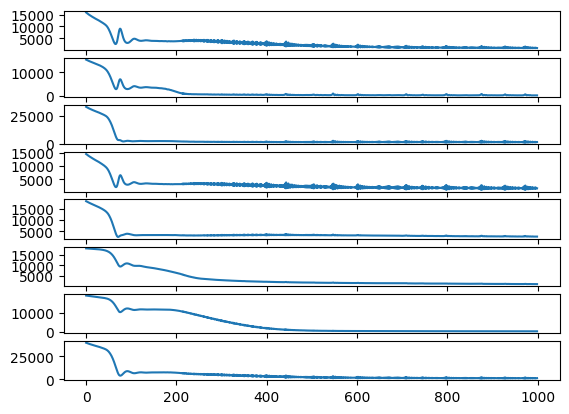

In [5]:
for i in range(8):
	plt.subplot(8,1,i+1)
	plt.plot(range(1000),ImgLoss[i])

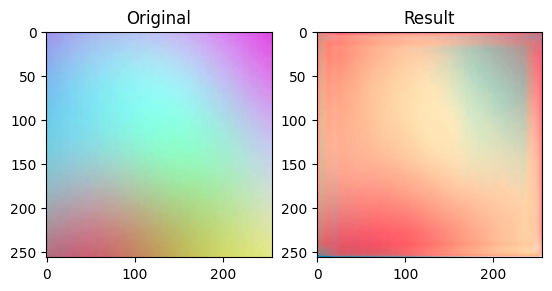

In [6]:
model.eval()
with torch.no_grad():
	TestImg = cv2.imread('Test.png')
	TestLab = cv2.cvtColor(TestImg,cv2.COLOR_BGR2LAB)
	TestInp = torch.from_numpy(TestLab[:,:,0:1]).float().permute(2,0,1).unsqueeze(0).to(device)
	TestOut = model(TestInp)
	TestResRaw = torch.concat((TestInp,TestOut),dim=1).squeeze(0).permute(1,2,0).cpu().detach().numpy()
	TestResNorm = np.clip(TestResRaw,0,255).astype(np.uint8)

	plt.subplot(1,2,1)
	plt.title('Original')
	plt.imshow(cv2.cvtColor(TestImg,cv2.COLOR_BGR2RGB))
	
	plt.subplot(1,2,2)
	plt.title('Result')
	plt.imshow(cv2.cvtColor(TestResNorm,cv2.COLOR_LAB2RGB))